# Image Captioning on the Flicker8k Dataset

This notebook provides you with a rough structure for the Mini-Challenge on the topic of Image Captioning from the Deep Learning MSE course. Please make sure to follow the Project Setup steps to ensure reproducable results. Additionally familiarize yourself with the grading structure and project submission guidelines in the _DL-MPW-ImgCaptioning.pdf_ document. There you'll find all the information you should need. 

If you have any questions please contact roman.studer@fhnw.ch

###  Team Name and Members

Team Name: accidentally_studying

Team Members:
- Joël Thauss
- Maurizio Piu


### Some Guidelines

- You are allowed to use generative models (e.g. ChatGPT, Claude etc.) for code completion or suggestions. However, we require you to perfectly understand and control the code. 
- You are **not** allowed to use the same or similar generative models for providing reflection on the achieved results. __You__ must reflect about what you see and build your own opinion about it.
- You are allowed to create additional python scripts to outsource code snippets to improve readability.

## Project Setup


### 1. Create the virtual environment

Create a new environment and install the necessary dependencies listed in `requirements.txt`. Make sure you can import the libraries in the code cell below and that yout pytorch installation can run on your GPU.

In [40]:
# imports
import textwrap

import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision

from dataloader import (
    build_tokenizer_from_split,
    create_caption_dataloader
)
from tokenizer import tokenize

print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

# TODO: Add your own imports here, if needed.
import torchvision.models as models
import torch.nn as nn
from tqdm import tqdm
from utils import save_checkpoint, load_checkpoint

torch version: 2.12.0
torchvision version: 0.27.0


### 2. Download the dataset
The Flickr8k dataset used in this challenge is available under [Flickr 8k Dataset - Kaggle](https://www.kaggle.com/datasets/adityajn105/flickr8k). In the zip folder on Moodle you find the basic structure with `captions.txt` and the `data/splits`-folder, but without images in the `data/ìmages`-folder. Make sure to download all the images and placing them in the folder `data/images/`. 
The train test split is already provided for you and handled by the provided `dataloader.py` script. Test and train split image lists and corresponding captions are located in the `data/splits/` folder. Don't modify this split.

<img src="data_structure.png"/>

## Dataloader, Tokenizer

The repository includes a `Dataset`-class (`Flickr8kCaptionsDatasetBase`) and `DataLoader`'s that are based on this specific structure of the data directory. You can use `create_caption_dataloader` for obtaining instances for the train and test data loaders. You can configure it with the `tokenizer` provided in the repo. The `tokenizer` performs some preprocessing steps of the captions. It also creates a vocabulary from the training data and then provides a mapping from the words to tokens. Note that there are also some special tokens introduced that are important when processing the captions during training or generating the captions during inference:
| Word    | ID | Role |
| --------| ---|----- |
| `<pad>`  | 0 | padding for filling up sequence to a given length in a mini-batch. | 
| `<bos>`  | 1 | beginning of sentence - each tokenized sentence should start with `<bos>`, i.e. also the generated ones. | 
| `<eos>`  | 2 | end of sentence - for fixed length captions will signal that the rest will consist of `<pad>`-tokens only. | 
| `<unk>`  | 3 | unknown - not available in vocabulary | 

Furthermore, specify your transforms used for preprocessing and augmenting the images and pass them to the `create_caption_dataloader`-method.
The mini-batches created by the dataloader have the following structure: `(images, captions, lengths, image_ids, raw_captions)`. Captions are built from the training vocabulary only, and `lengths` may let you mask padding tokens in the loss.


In [41]:
# Transforms
from torchvision import transforms

IMAGENET_SIZE = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def _convert_to_rgb(image: Image.Image) -> Image.Image:
    return image.convert("RGB")

def build_train_transforms() -> transforms.Compose:
    return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            # START - MODIFY / EXTEND THIS PART
            transforms.Resize((IMAGENET_SIZE,IMAGENET_SIZE)),
            # END - MODIFY / EXTEND THIS PART
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

def build_test_transforms() -> transforms.Compose:
    return transforms.Compose([
            transforms.Lambda(_convert_to_rgb),
            transforms.Resize((IMAGENET_SIZE,IMAGENET_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

def denormalize_image(image: torch.Tensor) -> torch.Tensor:
    """Undo ImageNet normalization for visualization."""
    mean_tensor = image.new_tensor(IMAGENET_MEAN).view(-1, 1, 1)
    std_tensor = image.new_tensor(IMAGENET_STD).view(-1, 1, 1)
    return (image * std_tensor + mean_tensor).clamp(0, 1)

In [42]:
# DONE: ADJUST PATH TO data_dir IF NEEDED
data_dir = "./data/"

# TODO: SET REASONABLE VALUES FOR THE FOLLOWING PARAMETERS
MIN_WORD_FREQ = 5
MAX_LEN = 40
BATCH_SIZE = 32

In [43]:
# TODO: POSSIBLY USE YOUR OWN TOKENIZER AND SET IT TO tokenizer=YourTokenizer(...)
# Make sure to build the vocabulary only from training captions to avoid test leakage.

tokenizer = build_tokenizer_from_split(split="train", data_dir = data_dir, min_freq=MIN_WORD_FREQ)

train_loader = create_caption_dataloader(
    split="train", 
    data_dir = data_dir, 
    tokenizer=tokenizer, 
    transform = build_train_transforms(),
    batch_size = BATCH_SIZE, 
    max_len=MAX_LEN, 
    caption_sampling="all")
test_loader = create_caption_dataloader(
    split="test", 
    data_dir = data_dir, 
    tokenizer=tokenizer, 
    transform = build_test_transforms(),
    batch_size = BATCH_SIZE, 
    max_len=MAX_LEN, 
    caption_sampling="random")

images, captions, lengths, image_ids, raw_captions = next(iter(train_loader))

print(f"Vocabulary size: {len(tokenizer):,}")
print(f"Number of training examples: {len(train_loader.dataset):,}")
print(f"Batch image tensor shape: {tuple(images.shape)}")
print(f"Batch caption tensor shape: {tuple(captions.shape)}")
print(f"Caption lengths in first batch: {lengths.tolist()}")

images, captions, lengths, image_ids, raw_captions = next(iter(test_loader))

print(f"Number of test examples: {len(test_loader.dataset):,}")
print(f"Batch image tensor shape: {tuple(images.shape)}")
print(f"Batch caption tensor shape: {tuple(captions.shape)}")
print(f"Caption lengths in first batch: {lengths.tolist()}")

/Users/mauri/Documents/projects/master_dev/FTP_DeepLearning/github/ftp_de_learn/MPW_03/captioning_starter/dataloader.py:55: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  captions_df["image"] = captions_df["image"].astype(str)
/Users/mauri/Do

Vocabulary size: 2,649
Number of training examples: 32,365
Batch image tensor shape: (32, 3, 224, 224)
Batch caption tensor shape: (32, 40)
Caption lengths in first batch: [11, 10, 12, 11, 17, 15, 10, 9, 16, 11, 16, 12, 17, 11, 12, 12, 11, 14, 13, 13, 13, 8, 14, 8, 13, 10, 17, 23, 9, 14, 12, 13]
Number of test examples: 1,618
Batch image tensor shape: (32, 3, 224, 224)
Batch caption tensor shape: (32, 40)
Caption lengths in first batch: [21, 20, 13, 20, 11, 10, 10, 7, 13, 11, 12, 7, 10, 17, 10, 6, 12, 10, 14, 8, 18, 10, 9, 12, 12, 9, 9, 17, 24, 20, 10, 9]


INFO: The above code uses deprecated functionality, that throws warnings for the code call in dataloader.py:55

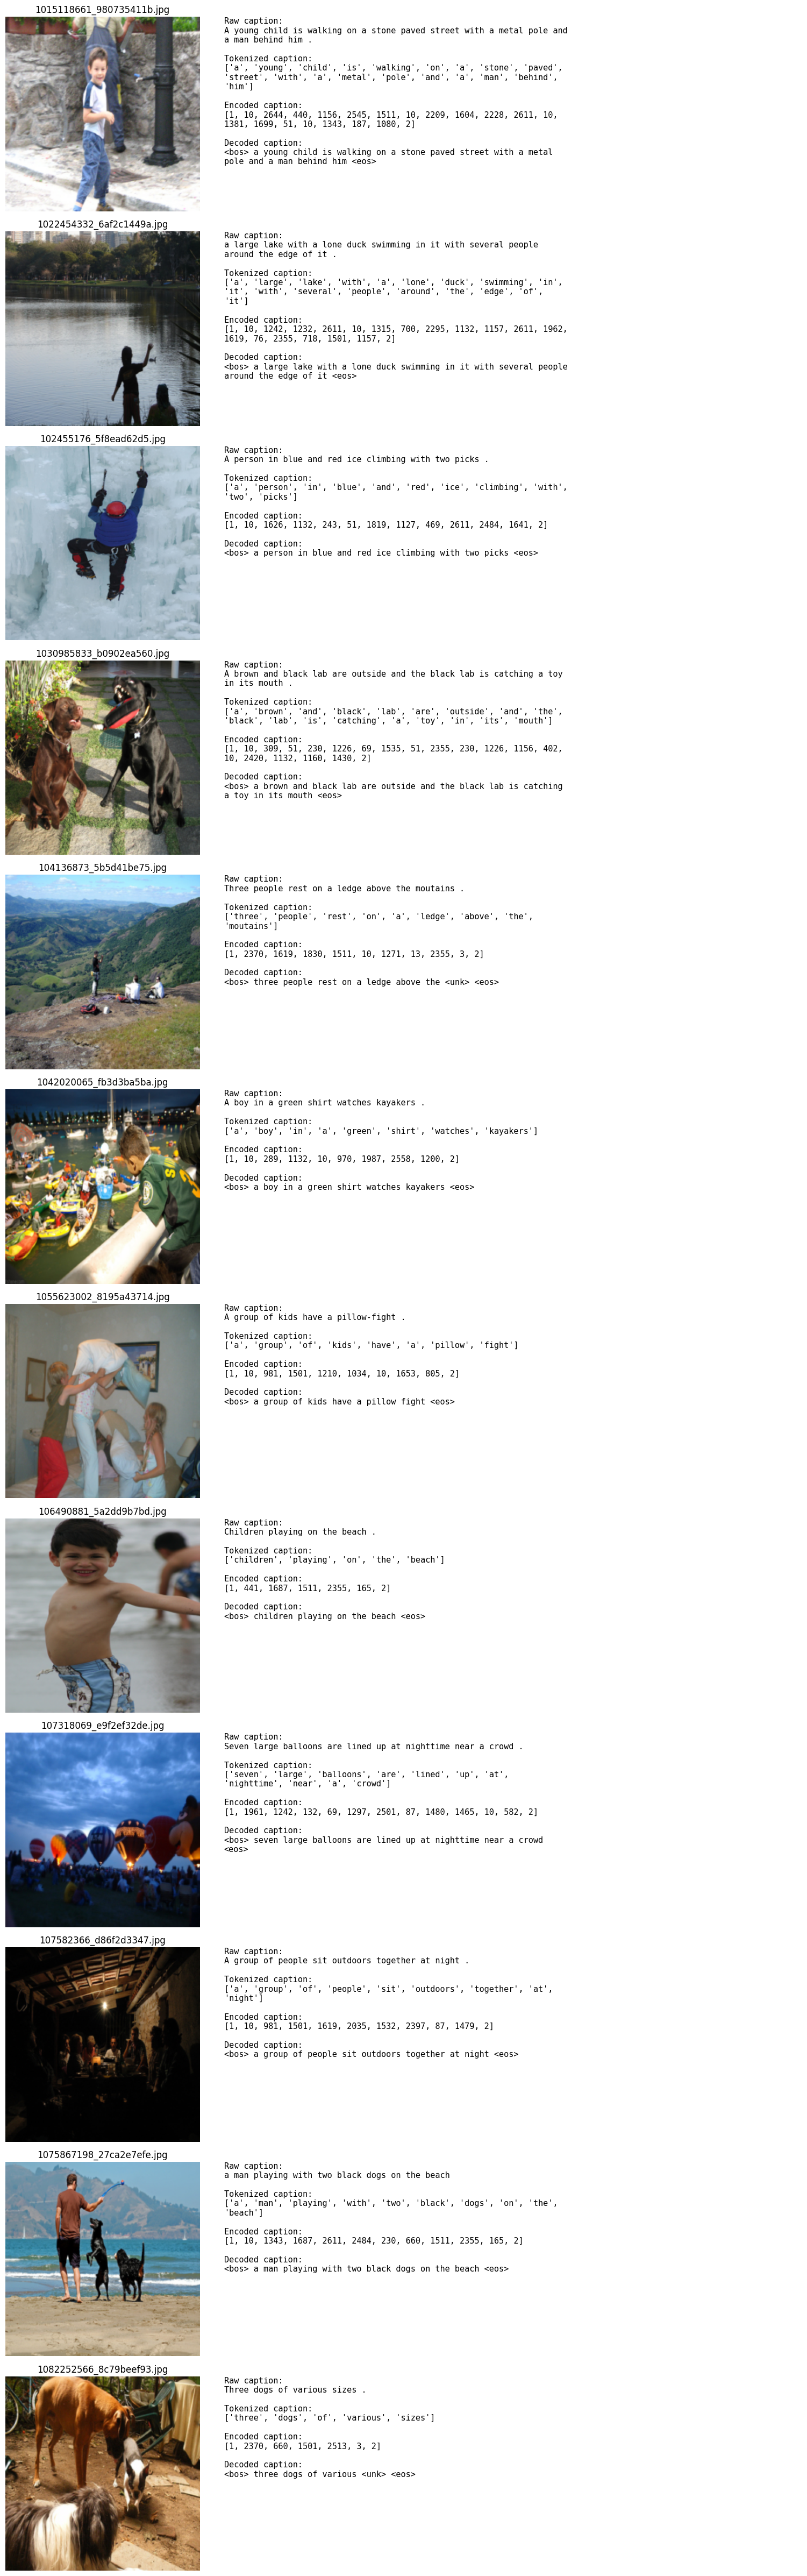

In [44]:
num_examples = 12
n = min(num_examples, len(images))

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(16, 4 * n),
    gridspec_kw={"width_ratios": [1.1, 2.2]},
)

if n == 1:
    axes = [axes]

for idx in range(n):
    image = denormalize_image(images[idx].detach().cpu()).permute(1, 2, 0)

    encoded_caption = captions[idx, : int(lengths[idx])].tolist()
    tokenized_caption = tokenize(raw_captions[idx])
    decoded_caption = tokenizer.decode(encoded_caption, skip_special_tokens=False)

    ax_image, ax_text = axes[idx]
    ax_image.imshow(image)
    ax_image.set_title(image_ids[idx])
    ax_image.axis("off")

    caption_details = "\n\n".join(
        [
            f"Raw caption:\n{textwrap.fill(raw_captions[idx], width=70)}",
            f"Tokenized caption:\n{textwrap.fill(str(tokenized_caption), width=70)}",
            f"Encoded caption:\n{textwrap.fill(str(encoded_caption), width=70)}",
            f"Decoded caption:\n{textwrap.fill(decoded_caption, width=70)}",
        ]
    )

    ax_text.axis("off")
    ax_text.text(
        0,
        1,
        caption_details,
        va="top",
        ha="left",
        fontsize=11,
        family="monospace",
    )

plt.tight_layout()
plt.show()

## Shared Utilities

Use this section for shared config and helper functions reused across all experiments. For example define a common training loop, BLEU computation or visualization helpers here. This way your model models stay directly comparable.


In [45]:
# Define shared config, helper functions, a fixed evaluation subset, and BLEU computation.
DEVICE = None
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else: 
    DEVICE = torch.device("cpu")

print("device:", DEVICE)


# further helper functionality:
# ...

device: mps


## Model 1 - Show and Tell

Implement the model described in the [_Show and Tell_](https://arxiv.org/abs/1411.4555) paper . Record the training behavior, inspect a few generated captions on held-out images, and report BLEU on your fixed evaluation subset.

In [46]:
# TODO Implement the Show and Tell model classes and any model-specific setup here.

DROPOUT = 0.3

# a pretrained CNN encoder
class ShowAndTellEncoder(nn.Module):
    def __init__(self, embed_dim):
        super(ShowAndTellEncoder, self).__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Replace the classifier head: 512 → embed_dim
        resnet.fc = nn.Linear(resnet.fc.in_features, embed_dim)
        self.resnet = resnet
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        # images: (B, 3, 224, 224) → features: (B, embed_dim)
        features = self.resnet(images)
        return self.dropout(self.relu(features))

# an LSTM-based decoder
class ShowAndTellDecoder(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size, num_layers):
        super(ShowAndTellDecoder, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers)
        self.linear = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, features: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        # features: (B, embed_dim)
        # captions: (seq_len, B)  ← sequence-first
        embeddings = self.dropout(self.embed(captions)) # (seq_len, B, embed_dim)
        embeddings = torch.cat((features.unsqueeze(0), embeddings), dim=0) # (seq_len+1, B, embed_dim)
        hiddens, _ = self.lstm(embeddings) # (seq_len+1, B, hidden_dim)
        outputs = self.linear(hiddens) # (seq_len+1, B, vocab_size)
        return outputs

# Captioner: Connecting Encoder and Decoder
class ShowAndTellCaptioner(nn.Module):
    def __init__(self, embed_dim, hidden_dim, vocab_size, num_layers):
        super(ShowAndTellCaptioner, self).__init__()
        self.encoderCNN = ShowAndTellEncoder(embed_dim)
        self.decoderRNN = ShowAndTellDecoder(embed_dim, hidden_dim, vocab_size, num_layers)

    def forward(self, images: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        # images: (B, 3, 224, 224)
        # captions: (seq_len, B) // already transposed before calling
        features = self.encoderCNN(images)          # (B, embed_dim)
        outputs = self.decoderRNN(features, captions)  # (seq_len+1, B, vocab_size)
        return outputs

    @torch.no_grad()
    def generate(self, image: torch.Tensor, max_len: int = 35) -> str:
        # image: (1, 3, 224, 224) — single image, batch size 1
        self.eval()
        result_ids = []

        # Encode image, treat as first LSTM input
        x = self.encoderCNN(image).unsqueeze(0) # (1, 1, embed_dim)
        states = None

        for _ in range(max_len):
            hiddens, states = self.decoderRNN.lstm(x, states) # hiddens: (1, 1, hidden_dim)
            output = self.decoderRNN.linear(hiddens.squeeze(0)) # (1, vocab_size)
            predicted = output.argmax(dim=1) # (1,)

            token_id = predicted.item()
            if token_id == tokenizer.eos_idx:
                break

            result_ids.append(token_id)
            x = self.decoderRNN.embed(predicted).unsqueeze(0) # (1, 1, embed_dim)

        return tokenizer.decode(result_ids)

In [50]:
# TODO Hyperparameters for the Show and Tell architecture  
# ENCODER_DIM = 256 # 
# EMBED_DIM = tokenizer.vocab_size # vocab size
# DECODER_DIM = 256 # hidden dim
# #FREEZE_ENCODER = 

# Hyperparameters
embed_size = 256
hidden_size = 512
vocab_size = tokenizer.vocab_size
num_layers = 1
learning_rate = 3e-4
num_epochs = 5

In [51]:
# TODO: Add the training loop, caption generation, evaluation and metric calculation logic for Model 1 here and in the following cells.

ds_train = train_loader.dataset

def train_show_and_tell():
    model = ShowAndTellCaptioner(embed_size, hidden_size, vocab_size, num_layers).to(DEVICE)
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_idx)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Freeze all ResNet layers except the new fc head
    for name, param in model.encoderCNN.resnet.named_parameters():
        param.requires_grad = ("fc.weight" in name or "fc.bias" in name)

    model.train()

    for epoch in range(num_epochs):
        total_loss = 0.0

        for imgs, captions, lengths, image_ids, raw_captions in tqdm(train_loader, leave=False):
            imgs = imgs.to(DEVICE)
            captions = captions.to(DEVICE)
            captions = captions.T  # (B, T) ->(T, B)

            # forward pass with teacher forcing
            outputs = model(imgs, captions[:-1])    # outputs: (T, B, vocab_size)

            # outputs has T predictions; targets are the T tokens in captions
            loss = criterion(
                outputs.reshape(-1, outputs.shape[2]),  # (T*B, vocab_size)
                captions.reshape(-1)                    # (T*B,)
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # gradient clipping to prevent exploding gradients
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {avg_loss:.4f}")

    return model

sat_model = train_show_and_tell()

Epoch [1/5] Loss: 3.7473


Epoch [2/5] Loss: 3.0913


Epoch [3/5] Loss: 2.8483


Epoch [4/5] Loss: 2.6941


Epoch [5/5] Loss: 2.5824


Briefly summarize what happened during training, which captions looked convincing or weak, and what the BLEU score does or does not capture for this model.


<span style="color: red;"><strong>TODO:</strong> Write your reflection on Model 1 here.</span>


## Model 2 - Show, Attend and Tell

Now implement the continuation of the Show and Tell paper. An attention-based captioning model described in the paper [_Show, Attend and Tell_](https://arxiv.org/abs/1502.03044). Use the same test data subset and BLEU setup as before, then compare how attention changes the training behavior and generated captions.


In [ ]:
# TODO Parameters for the Show, Attend and Tell Architecture
ENCODER_DIM = 
EMBED_DIM = 
DECODER_DIM = 
DROPOUT = 
FREEZE_ENCODER = 
ATTENTION_DIM = 

In [ ]:
class ShowAttendTellEncoder(nn.Module):
    def __init__(self, ...):
        # TODO
    def forward(self, images: torch.Tensor) -> torch.Tensor:
        # TODO


class AdditiveAttention(nn.Module):
    def __init__(self, ....):
        # TODO
    def forward(self, encoder_out: torch.Tensor, decoder_hidden: torch.Tensor):
        # encoder_out: (B, num_pixels, encoder_dim)
        # decoder_hidden: (B, decoder_dim)
        # TODO

class ShowAttendTellCaptioner(nn.Module):
    def __init__(self, ...):
        # TODO

    def forward(self, images: torch.Tensor, captions: torch.Tensor) -> torch.Tensor:
        # TODO

    @torch.no_grad()
    def generate(self, images: torch.Tensor, max_len=35) -> torch.Tensor:
        # TODO

In [ ]:
# TODO: Add the training loop, caption generation, evaluation and metric calculation logic for Model 2 here and in the following cells.

Briefly summarize how this model behaved during training, where attention seemed to help or fail, and how the BLEU score compares to Model 2.


<span style="color: red;"><strong>TODO:</strong> Write your reflection on Model 2 here.</span>


## Additional Task 1: Option ...

Formulate and rationalize a hypothesis.

Carry through an experiment for testing this hypothesis.

Describe the outcome and carefully evaluate and reflect about it. 

## Additional Task 2: Option ....

Formulate and rationalize a hypothesis.

Carry through an experiment for testing this hypothesis.

Describe the outcome and carefully evaluate and reflect about it. 